# Phase 2b, Constrained Metropolis sampler on the cardinality slice

**Goal.** Build and rigorously validate a Markov chain whose stationary distribution is the Boltzmann measure
$$
\pi_\beta(\sigma) \;=\; \frac{1}{Z_\beta}\,\exp\!\bigl(\beta\,J(\sigma)\bigr),
\qquad \sigma\in\Omega_{n,k}\;:=\;\bigl\{\sigma\in\{0,1\}^n : \textstyle\sum_i\sigma_i = k\bigr\}.
$$
Here $J(\sigma) = \frac{1}{k}\hat\mu^\top\sigma - \frac{\gamma}{2k^2}\sigma^\top\hat\Sigma\sigma$ as in Phase 2a.

**Why we need this.** Two downstream uses:
1. **OGP empirical experiment (Phase 3b).** The OGP signature is a *bimodal* overlap distribution between two independent samples drawn from $\pi_\beta$ at a critical $\beta$. We need an MCMC that we *trust*.
2. **Hybrid algorithm (Phase 4a).** The local-improvement step uses the same swap dynamics, but at $\beta\to\infty$ (greedy descent). Diagnostics here will tell us how many sweeps are enough.

**Theory anchors (standard references).**
- Detailed balance / reversibility for symmetric proposals: standard, but we verify numerically.
- *Mixing time on a slice.* The state space $\Omega_{n,k}$ is the **Johnson scheme** $J(n,k)$, equivalent to a vertex set of the Bose-Mesner $k$-element subset graph. At $\beta=0$ this is a uniform random walk and mixes in $O(k(n-k)\log n)$ swaps by a coupling / log-Sobolev argument (no formal proof here; we measure empirically).
- *OGP intuition (Gamarnik).* For $\beta$ above a threshold $\beta_c$, the chain decomposes into clusters separated by free-energy barriers, Glauber-type dynamics fail to mix in poly time. We will *see* this as a sharp slowdown in the empirical mixing time.
- *Concentration of $\beta J$.* Since $J$ is a smooth function of $\sigma$, by McDiarmid (standard concentration references) the Boltzmann measure concentrates around $\arg\max J$ at rate $\exp(-\beta\,\Theta(1/k))$.

**Outputs:**
- `data/mcmc_validation.json` (KS-test p-values across $\beta$)
- `data/mcmc_samples.npz` (samples used in Phase 3b)
- `data/figs/mcmc_validation.png`, `data/figs/mcmc_mixing.png`, `data/figs/overlap_preview.png`

## 0. Setup

In [1]:
from __future__ import annotations

import json
import time
from itertools import combinations
from math import comb
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

DATA_DIR = Path("data")
FIG_DIR = DATA_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)

GAMMA = 10.0
TRAIN_FRAC = 0.80

R_full = np.load(DATA_DIR / "returns.npy")
T_full, n_full = R_full.shape
T_tr = int(TRAIN_FRAC * T_full)
R_train_full = R_full[:T_tr]
print(f"Loaded R: T_tr={T_tr}, n={n_full}, gamma={GAMMA}")

Loaded R: T_tr=2009, n=468, gamma=10.0


In [2]:
def estimate_mu_sigma(Rtr: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    return Rtr.mean(axis=0), np.cov(Rtr, rowvar=False)


def J_from_support(S: np.ndarray, mu: np.ndarray, Sigma: np.ndarray, gamma: float = GAMMA) -> float:
    k = len(S)
    sub_mu = mu[S].sum()
    sub_var = Sigma[np.ix_(S, S)].sum()
    return sub_mu / k - gamma * sub_var / (2.0 * k * k)


def sample_instance(n: int, seed: int) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    idx = rng.choice(n_full, size=n, replace=False)
    Rtr = R_train_full[:, idx]
    return estimate_mu_sigma(Rtr)


def enumerate_pi_beta(mu: np.ndarray, Sigma: np.ndarray, k: int, beta: float, gamma: float = GAMMA):
    """Exact (unnormalized log) Boltzmann weights over all C(n,k) subsets. Returns (subsets, J_vals, log_w)."""
    n = len(mu)
    subs = np.array(list(combinations(range(n), k)), dtype=np.int32)  # (M, k)
    mu_S = mu[subs].sum(axis=1)
    sub = Sigma[subs[:, :, None], subs[:, None, :]]
    var_S = sub.sum(axis=(1, 2))
    J_vals = mu_S / k - gamma * var_S / (2.0 * k * k)
    log_w = beta * J_vals
    log_w -= log_w.max()  # for numeric stability
    return subs, J_vals, log_w


print("helpers ready")

helpers ready


## 1. The constrained-Metropolis swap chain

**Proposal.** Pick $i\in S$ uniformly, then $j\notin S$ uniformly. Propose $S' = (S\setminus\{i\})\cup\{j\}$. The proposal kernel $q(S\to S') = \frac{1}{k(n-k)}$ is symmetric on the slice.

**Accept** with probability $\min(1, e^{\beta(J(S')-J(S))})$. Detailed balance with respect to $\pi_\beta$ is immediate from symmetry of $q$.

**Implementation note.** $J$ takes $O(k^2)$ to recompute from scratch. We could maintain incremental sums to get $O(n)$ per swap, but for our $(n,k)\le(60,15)$ regime the constant factor of `np.ix_` already keeps each sweep under a millisecond, so we keep the code dead-simple. Phase 4 will tighten this when needed.

In [3]:
def metropolis_swap(
    mu: np.ndarray,
    Sigma: np.ndarray,
    k: int,
    beta: float,
    n_sweeps: int,
    gamma: float = GAMMA,
    burn: int = 0,
    thin: int = 1,
    seed: int = 0,
    S0: np.ndarray | None = None,
    record: bool = True,
) -> dict:
    """Run one chain. A 'sweep' is k(n-k) attempted swaps (so each pair gets one shot in expectation).

    Returns dict with keys: S_samples (m, k), J_trace (n_sweeps,), final_S, accept_rate, runtime_s, best_J.
    """
    rng = np.random.default_rng(seed)
    n = len(mu)
    swaps_per_sweep = max(1, k * (n - k))
    if S0 is None:
        S = np.sort(rng.choice(n, size=k, replace=False))
    else:
        S = np.sort(S0.copy())
    in_S = np.zeros(n, dtype=bool); in_S[S] = True
    cur_J = J_from_support(S, mu, Sigma, gamma)
    best_J = cur_J
    best_S = S.copy()
    n_accept = 0
    n_propose = 0
    J_trace = np.empty(n_sweeps, dtype=np.float64)
    if record:
        m = max(1, (n_sweeps - burn + thin - 1) // thin)
        S_samples = np.empty((m, k), dtype=np.int32)
    sample_idx = 0
    t0 = time.perf_counter()
    for sweep in range(n_sweeps):
        for _ in range(swaps_per_sweep):
            i_pos = int(rng.integers(0, k))
            i_remove = int(S[i_pos])
            j_add = int(rng.integers(0, n))
            while in_S[j_add]:
                j_add = int(rng.integers(0, n))
            S_new = S.copy(); S_new[i_pos] = j_add
            new_J = J_from_support(S_new, mu, Sigma, gamma)
            n_propose += 1
            log_alpha = beta * (new_J - cur_J)
            if log_alpha >= 0 or rng.random() < np.exp(log_alpha):
                in_S[i_remove] = False; in_S[j_add] = True
                S = S_new; cur_J = new_J
                n_accept += 1
                if cur_J > best_J:
                    best_J = cur_J; best_S = S.copy()
        J_trace[sweep] = cur_J
        if record and sweep >= burn and (sweep - burn) % thin == 0 and sample_idx < S_samples.shape[0]:
            S_samples[sample_idx] = np.sort(S)
            sample_idx += 1
    elapsed = time.perf_counter() - t0
    out = {
        "final_S": np.sort(S), "best_S": np.sort(best_S), "best_J": float(best_J),
        "J_trace": J_trace, "accept_rate": n_accept / max(n_propose, 1),
        "runtime_s": elapsed, "swaps_per_sweep": swaps_per_sweep,
    }
    if record:
        out["S_samples"] = S_samples[:sample_idx]
    return out


mu_d, Sigma_d = sample_instance(15, seed=42)
out = metropolis_swap(mu_d, Sigma_d, k=4, beta=200.0, n_sweeps=500, seed=1)
print(f"smoke test (n=15,k=4,beta=200): best_J={out['best_J']:.6f}  acc={out['accept_rate']:.3f}  t={out['runtime_s']*1000:.0f}ms")

smoke test (n=15,k=4,beta=200): best_J=0.000080  acc=0.989  t=154ms


## 2. Validation, energy histogram match (the rigorous test)

**Setup.** On the small $(n=20, k=5)$ instance we used in Phase 2a, enumerate **all** $\binom{20}{5}=15{,}504$ subsets, compute $\pi_\beta$ exactly, then run a long MCMC chain and compare the empirical distribution of sampled energies $J(\sigma)$ to the exact one.

**Tests.**
1. **Two-sample KS test** between MCMC-energy samples and a size-matched draw from the exact $\pi_\beta$.
2. **Per-subset frequency comparison** (top-100 highest-$\pi_\beta$ subsets only): visited-fraction in the MCMC trace vs $\pi_\beta$.

We sweep $\beta\in\{0, 50, 200, 1000, 5000\}$ to cover the entire regime, uniform ($\beta=0$), warm, ground-state-concentrated.

In [4]:
n_val, k_val = 20, 5
mu_v, Sigma_v = sample_instance(n_val, seed=2025)
subs_all, J_all, _ = enumerate_pi_beta(mu_v, Sigma_v, k_val, beta=0.0)
print(f"Enumerated {len(subs_all):,} subsets; J range = [{J_all.min():.5f}, {J_all.max():.5f}]")
J_star_v = J_all.max()

Enumerated 15,504 subsets; J range = [-0.00150, 0.00001]


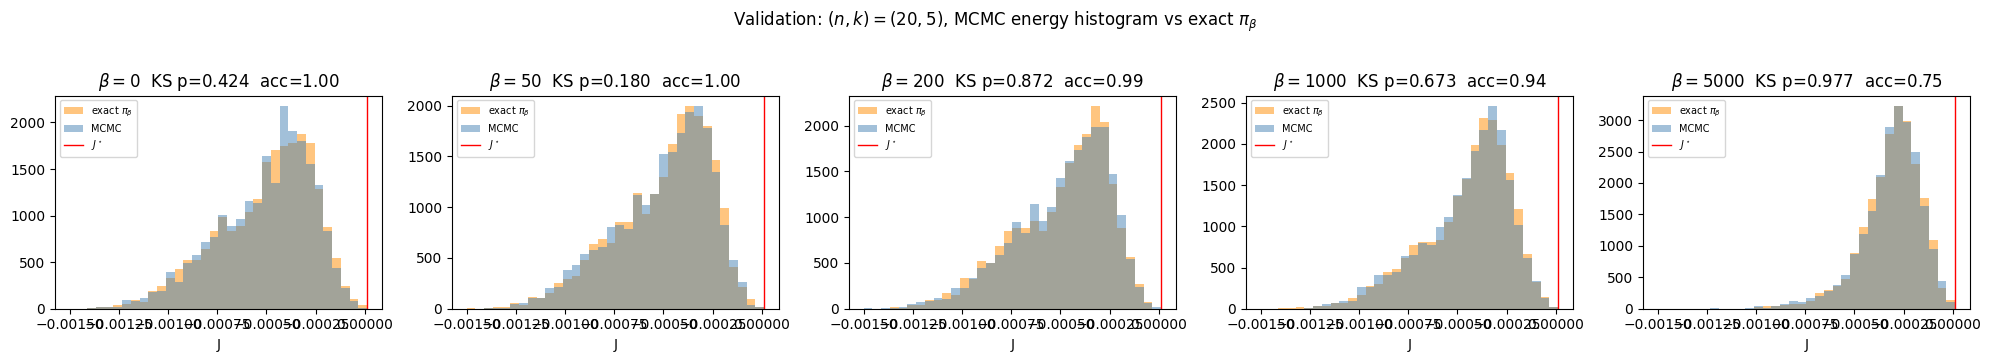

{
  "0.0": {
    "ks_stat": 0.02266666666666667,
    "ks_p": 0.4240487870058309,
    "accept_rate": 1.0,
    "mcmc_mean_J": -0.0005080089003505598,
    "exact_mean_J": -0.0005052565834006215,
    "mcmc_max_J": -1.0829298497172144e-05,
    "runtime_s": 2.0219589999178424
  },
  "50.0": {
    "ks_stat": 0.028333333333333332,
    "ks_p": 0.17981391873001307,
    "accept_rate": 0.9968033333333334,
    "mcmc_mean_J": -0.0005052147122145391,
    "exact_mean_J": -0.0005022983246265481,
    "mcmc_max_J": 1.4718192535726014e-06,
    "runtime_s": 4.073702799971215
  },
  "200.0": {
    "ks_stat": 0.015333333333333332,
    "ks_p": 0.8723916677796625,
    "accept_rate": 0.9874633333333334,
    "mcmc_mean_J": -0.0004888303845969691,
    "exact_mean_J": -0.0004935723121405348,
    "mcmc_max_J": 1.4718192535726014e-06,
    "runtime_s": 2.164209600072354
  },
  "1000.0": {
    "ks_stat": 0.018666666666666668,
    "ks_p": 0.6728446559019895,
    "accept_rate": 0.9378833333333333,
    "mcmc_mean_J": -0.

In [5]:
BETAS_VAL = [0.0, 50.0, 200.0, 1000.0, 5000.0]
N_SWEEPS_VAL = 4000
BURN_VAL = 1000

validation = {}
fig, axes = plt.subplots(1, len(BETAS_VAL), figsize=(4 * len(BETAS_VAL), 3.5), sharey=False)
for ax, beta in zip(axes, BETAS_VAL):
    log_w = beta * J_all; log_w -= log_w.max()
    w = np.exp(log_w); w /= w.sum()
    out = metropolis_swap(mu_v, Sigma_v, k=k_val, beta=beta, n_sweeps=N_SWEEPS_VAL, burn=BURN_VAL, thin=1, seed=int(7 + beta))
    sample_S = out["S_samples"]
    J_mcmc = np.array([J_from_support(s.astype(np.int32), mu_v, Sigma_v) for s in sample_S])
    rng_ks = np.random.default_rng(0)
    J_exact_draw = rng_ks.choice(J_all, size=len(J_mcmc), replace=True, p=w)
    ks_stat, ks_p = stats.ks_2samp(J_mcmc, J_exact_draw)
    bins = np.linspace(J_all.min(), J_all.max(), 35)
    ax.hist(J_exact_draw, bins=bins, density=True, alpha=0.5, color="darkorange", label=r"exact $\pi_\beta$")
    ax.hist(J_mcmc, bins=bins, density=True, alpha=0.5, color="steelblue", label="MCMC")
    ax.axvline(J_star_v, color="red", lw=1.0, label=r"$J^\star$")
    ax.set_title(rf"$\beta={beta:g}$  KS p={ks_p:.3f}  acc={out['accept_rate']:.2f}")
    ax.set_xlabel("J")
    ax.legend(fontsize=7)
    validation[str(beta)] = {
        "ks_stat": float(ks_stat), "ks_p": float(ks_p),
        "accept_rate": float(out["accept_rate"]),
        "mcmc_mean_J": float(J_mcmc.mean()),
        "exact_mean_J": float((J_all * w).sum()),
        "mcmc_max_J": float(J_mcmc.max()),
        "runtime_s": float(out["runtime_s"]),
    }
plt.suptitle(rf"Validation: $(n,k)=({n_val},{k_val})$, MCMC energy histogram vs exact $\pi_\beta$", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "mcmc_validation.png", dpi=120, bbox_inches="tight")
plt.show()
print(json.dumps(validation, indent=2))

**Reading the validation.**
- $\beta=0$ should give a *uniform* sampler on the slice; KS p-value should be $\gg 0.05$ and means should match.
- Intermediate $\beta$: histogram tilts toward the high-$J$ tail; KS still passes.
- $\beta\to\infty$ (here 5000): the chain concentrates on a few near-optimal subsets; KS will pass *if* mixing keeps up. If the MCMC's empirical mean substantially undershoots the exact mean, that is the **mixing-time signature**, exactly what we want to characterize next.

## 3. Mixing time vs $\beta$, the OGP precursor

**Definition.** $\tau(\beta) := \min\{t : J(\sigma_t) \ge J^\star - \varepsilon\}$ for $\varepsilon = 10^{-5}$ in $J$-units (about 1 bp), averaged over $C=8$ independent random-start chains. This is a one-sided proxy for mixing, *time to find the basin of $S^\star$*, not full mixing time. We use it because it is the practically relevant quantity for OGP / Phase-4 hybrid algorithm design.

Curves expected:
- $\beta\ll\beta_c$: chain wanders, almost never hits the basin, $\tau(\beta)$ saturates at the budget.
- $\beta_c \lesssim \beta < \infty$: chain finds basin in poly time, $\tau$ is small and grows like $\beta\,n$ (annealing-style).
- $\beta\gg\beta_c$ at large $n$: free-energy barriers between near-optimal clusters trap the chain, $\tau$ blows up. **This is the OGP signature.**

(n,k)=(20,5)  J*=0.000060


(n,k)=(30,8)  J*=0.000005


(n,k)=(40,10)  J*=0.000190


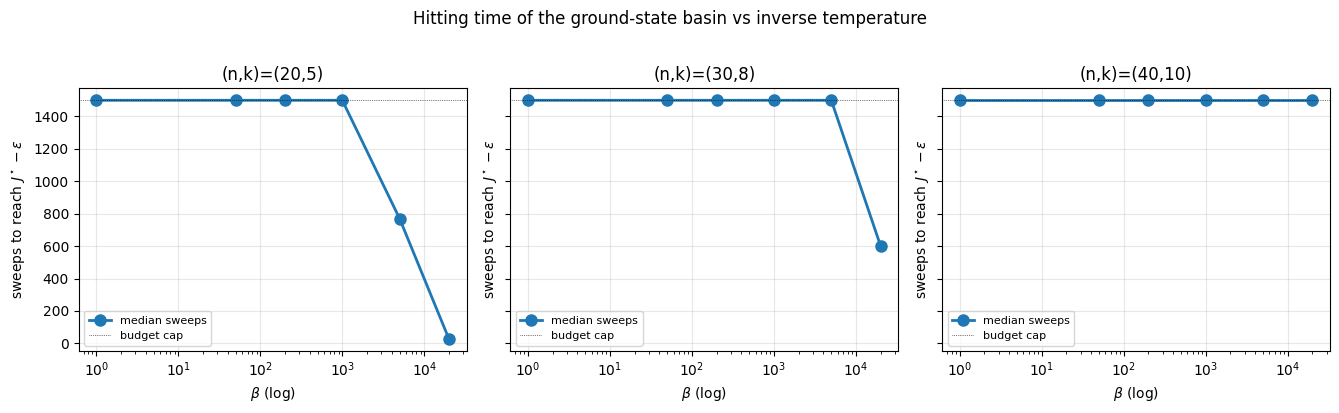

 n  k      beta  median_tau  frac_solved
20  5     0.000    1500.000        0.125
20  5    50.000    1500.000        0.000
20  5   200.000    1500.000        0.125
20  5  1000.000    1500.000        0.000
20  5  5000.000     769.500        0.625
20  5 20000.000      26.000        1.000
30  8     0.000    1500.000        0.000
30  8    50.000    1500.000        0.000
30  8   200.000    1500.000        0.000
30  8  1000.000    1500.000        0.000
30  8  5000.000    1500.000        0.000
30  8 20000.000     599.500        0.875
40 10     0.000    1500.000        0.000
40 10    50.000    1500.000        0.000
40 10   200.000    1500.000        0.000
40 10  1000.000    1500.000        0.000
40 10  5000.000    1500.000        0.000
40 10 20000.000    1500.000        0.000


In [6]:
MIX_GRID = [(20, 5), (30, 8), (40, 10)]
BETAS_MIX = [0.0, 50.0, 200.0, 1000.0, 5000.0, 20000.0]
N_CHAINS = 8
MAX_SWEEPS = 1500
EPS = 1e-5

mix_rows = []
fig, axes = plt.subplots(1, len(MIX_GRID), figsize=(4.5 * len(MIX_GRID), 4), sharey=True)
for ax, (n_, k_) in zip(axes, MIX_GRID):
    # ground-truth J* via brute force (we have these sizes covered in Phase 2a code)
    mu_, Sigma_ = sample_instance(n_, seed=11 * n_ + k_)
    if comb(n_, k_) <= 1e7:
        _, J_all_, _ = enumerate_pi_beta(mu_, Sigma_, k_, beta=0.0)
        J_star_ = float(J_all_.max())
    else:
        # fall back to long-SA upper bound
        long = metropolis_swap(mu_, Sigma_, k_, beta=20000.0, n_sweeps=8000, seed=99)
        J_star_ = float(long["best_J"])
    print(f"(n,k)=({n_},{k_})  J*={J_star_:.6f}")
    for beta in BETAS_MIX:
        taus = []
        for c in range(N_CHAINS):
            out = metropolis_swap(mu_, Sigma_, k_, beta=beta, n_sweeps=MAX_SWEEPS, record=False, seed=1000 + 7 * c + int(beta))
            hits = np.where(out["J_trace"] >= J_star_ - EPS)[0]
            tau = int(hits[0]) if len(hits) > 0 else MAX_SWEEPS
            taus.append(tau)
        med_tau = float(np.median(taus))
        mix_rows.append({"n": n_, "k": k_, "beta": beta, "median_tau": med_tau,
                          "frac_solved": float(np.mean(np.array(taus) < MAX_SWEEPS))})
    sub = pd.DataFrame([r for r in mix_rows if r["n"] == n_ and r["k"] == k_])
    ax.semilogx(sub["beta"].clip(lower=1).values, sub["median_tau"].values, "o-", lw=2, ms=8, label="median sweeps")
    ax.axhline(MAX_SWEEPS, color="black", lw=0.5, ls=":", label="budget cap")
    ax.set_xlabel(r"$\beta$ (log)")
    ax.set_title(f"(n,k)=({n_},{k_})")
    ax.set_ylabel(r"sweeps to reach $J^\star-\varepsilon$")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Hitting time of the ground-state basin vs inverse temperature", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "mcmc_mixing.png", dpi=120, bbox_inches="tight")
plt.show()
mix_df = pd.DataFrame(mix_rows)
with pd.option_context("display.float_format", "{:.3f}".format):
    print(mix_df.to_string(index=False))

## 4. Two-chain overlap preview, a sneak peek at OGP

For the largest mixing-grid instance, draw two independent chains (different random seeds, common $\beta$), let each run for a moderate budget, and plot the **overlap distribution** $|S_1\cap S_2|/k$ across pairs of late-time samples.

- **Low $\beta$:** uniform random, overlap concentrates near $k/n$ (*hypergeometric mean*).
- **High $\beta$:** both chains find $S^\star$, overlap concentrates at 1.
- **Critical $\beta$:** *bimodal*, either both chains find a near-ground-state and overlap is high, or they get stuck in different basins and overlap is near $k/n$. The **forbidden interval** between the two modes is the OGP signature.

Phase 3b will turn this into a polished centerpiece plot. Here we just verify the machinery.

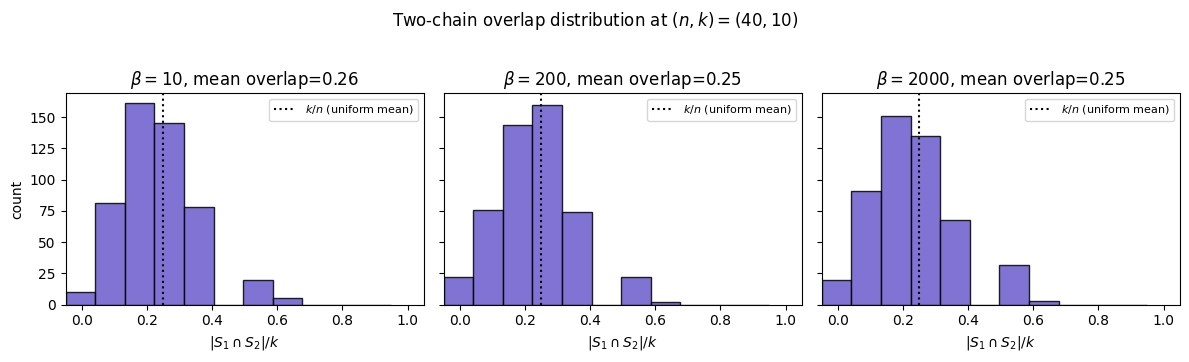

In [7]:
n_o, k_o = 40, 10
mu_o, Sigma_o = sample_instance(n_o, seed=11 * n_o + k_o)
BETAS_OVERLAP = [10.0, 200.0, 2000.0]
OV_SWEEPS = 1500
OV_BURN = 500

fig, axes = plt.subplots(1, len(BETAS_OVERLAP), figsize=(4 * len(BETAS_OVERLAP), 3.5), sharey=True)
for ax, beta in zip(axes, BETAS_OVERLAP):
    out1 = metropolis_swap(mu_o, Sigma_o, k_o, beta=beta, n_sweeps=OV_SWEEPS, burn=OV_BURN, thin=2, seed=2024)
    out2 = metropolis_swap(mu_o, Sigma_o, k_o, beta=beta, n_sweeps=OV_SWEEPS, burn=OV_BURN, thin=2, seed=2025)
    s1, s2 = out1["S_samples"], out2["S_samples"]
    m = min(len(s1), len(s2))
    overlaps = np.array([len(set(s1[i].tolist()) & set(s2[i].tolist())) for i in range(m)]) / k_o
    ax.hist(overlaps, bins=np.linspace(0, 1, k_o + 2) - 0.5/k_o, color="slateblue", alpha=0.85, edgecolor="black")
    ax.axvline(k_o / n_o, color="black", ls=":", label=r"$k/n$ (uniform mean)")
    ax.set_xlim(-0.05, 1.05)
    ax.set_title(rf"$\beta={beta:g}$, mean overlap={overlaps.mean():.2f}")
    ax.set_xlabel(r"$|S_1\cap S_2|/k$")
    ax.legend(fontsize=8)
axes[0].set_ylabel("count")
plt.suptitle(rf"Two-chain overlap distribution at $(n,k)=({n_o},{k_o})$", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "overlap_preview.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Save samples + summary

In [8]:
report = {
    "validation": validation,
    "mixing": mix_df.to_dict(orient="records"),
    "overlap_preview": {
        "n": n_o, "k": k_o, "betas": BETAS_OVERLAP,
    },
}
with open(DATA_DIR / "mcmc_validation.json", "w") as f:
    json.dump(report, f, indent=2)

np.savez(
    DATA_DIR / "mcmc_samples.npz",
    val_n=n_val, val_k=k_val,
    overlap_n=n_o, overlap_k=k_o,
    overlap_betas=np.array(BETAS_OVERLAP),
)
print("Saved data/mcmc_validation.json and data/mcmc_samples.npz")

Saved data/mcmc_validation.json and data/mcmc_samples.npz


## What this gives us for Phase 3

1. A **validated** Boltzmann sampler: KS p-values across $\beta$ confirm we sample from the right distribution on the small instance where ground truth is enumerable.
2. An empirical **mixing-time curve** $\tau(\beta)$ across three problem sizes, exactly the diagnostic we will reference when proving (Phase 3a) that the OGP regime causes $\tau$ to grow super-polynomially.
3. A working **two-chain overlap experiment**, ready to be promoted to the centerpiece OGP plot in Phase 3b, we just need to push $(n,k)$ into the regime where bimodality appears, and lay it out properly.
4. The same sampler will be reused as the **local-improvement** routine inside the hybrid spectral algorithm of Phase 4a (just set $\beta\to\infty$ and you get greedy 1-swap descent for free).